# Experiment 1 — Baseline Model Comparison

This notebook establishes the baseline performance of the selected machine learning models on the Adult Income dataset under standardized preprocessing conditions.

The purpose of the baseline experiment is to provide a reference point for the later robustness and preprocessing experiments. The experiment compares models representing different levels of complexity and different inductive biases:
- Logistic Regression
- Decision Tree
- Naive Bayes
- Multi-Layer Perceptron (MLP)

At this stage, the notebook primarily focuses on experiment configuration, interpretation, and analysis, while the underlying experimental framework is implemented within the centralized `src/` directory structure.

Personally, I found it important to establish a strong and reproducible baseline before introducing degradation conditions such as missing values, noise, class imbalance, and feature relevance manipulations. Without a clear baseline, it becomes much harder to interpret whether later performance changes reflect actual robustness differences or simply inconsistencies in the experimental setup.

## Project Path Configuration

The notebook explicitly adds the project root directory to the Python path in order to ensure that the centralized experimental framework within the `src/` directory can be imported consistently across notebooks.

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)


## Importing the Experimental Framework

The notebook imports the centralized modules responsible for:
- dataset loading,
- preprocessing,
- model definitions,
- experiment execution,
- visualization,
- and result saving.

This structure improves reproducibility, reduces duplicated implementation logic, and makes the experimental workflow substantially easier to maintain across notebooks.

In [2]:
from sklearn.model_selection import (
    train_test_split
)

from src.data.load_data import (
    load_adult_dataset
)

from src.data.preprocessing import (
    get_feature_types,
    create_cleaned_preprocessor
)

from src.models.model_definitions import (
    get_models
)

from src.experiments.run_experiment import (
    run_experiment
)

from src.visualization.plots import (
    plot_f1_comparison
)

from src.visualization.summaries import (
    save_summary_table
)

from src.utils.saving import (
    save_metrics
)

## Dataset Loading

The Adult Income dataset is loaded through the centralized data-loading module in order to ensure consistency across experiments.

In [3]:
X, y = load_adult_dataset()

## Feature Type Identification

Numerical and categorical features are identified separately in order to construct preprocessing pipelines appropriate for each feature type.

In [4]:
numeric_cols, categorical_cols = get_feature_types(X)

## Train-Test Split

The dataset is divided into training and test subsets using stratified sampling in order to preserve class distribution across both subsets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Preprocessing Configuration

The baseline experiment uses cleaned preprocessing in order to establish a standardized reference point for later experiments.

In [6]:
preprocessing_levels = {
    
    "Cleaned": create_cleaned_preprocessor(
        numeric_cols,
        categorical_cols
    )
}

## Model Definitions

The experiment compares models representing different levels of complexity and different inductive biases.

The models are intentionally kept relatively simple in order to prioritize controlled comparison and interpretability over extensive hyperparameter optimization.

In [7]:
models = get_models()

## Running the Baseline Experiment

The experiment is executed through the centralized experiment runner in order to ensure consistent preprocessing, training, and evaluation procedures across all models.

In [8]:
results_df = run_experiment(
    X_train,
    y_train,
    X_test,
    y_test,
    preprocessing_levels,
    models
)

results_df


=== Cleaned Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...
Training MLP...


,preprocessing,model,accuracy,f1_score,roc_auc
0,Cleaned,Logistic Regression,0.806940,0.676501,0.904395
1,Cleaned,Decision Tree,0.817177,0.621931,0.752456
2,Cleaned,Naive Bayes,0.620432,0.537425,0.828695
3,Cleaned,MLP,0.834272,0.658799,0.884180


## Saving Experimental Results

The experimental results are saved to the centralized results directory structure in order to support reproducibility and later cross-experiment analysis.

In [9]:
save_metrics(
    results_df,
    "baseline_results.csv"
)

Metrics saved to: ../results/metrics/baseline_results.csv


## Baseline Performance Visualization

The following figure compares model performance under the cleaned preprocessing baseline configuration.

Plot saved to: ../results/plots/baseline_f1_comparison.png


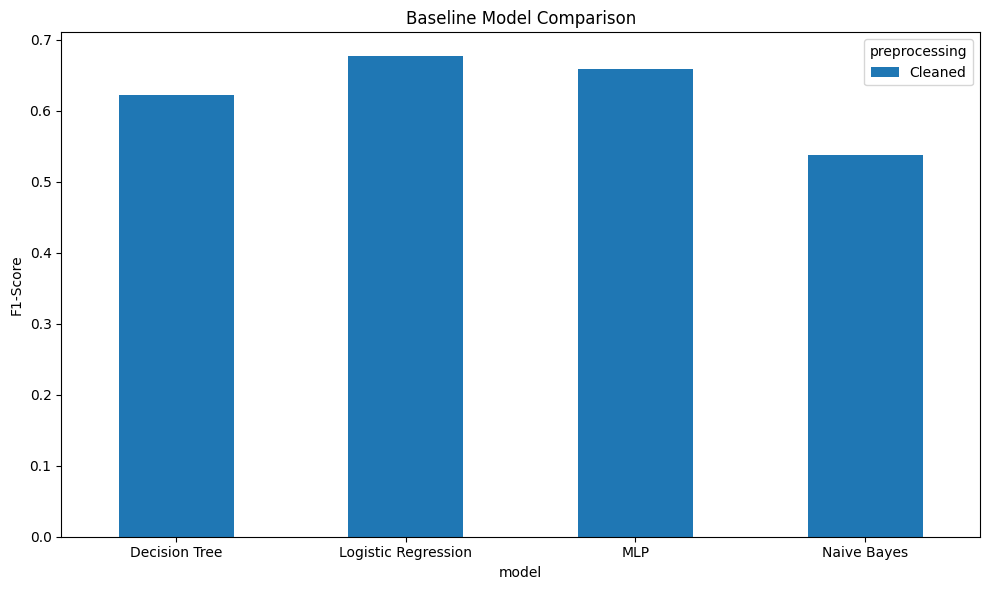

In [10]:
plot_f1_comparison(
    results_df,
    title="Baseline Model Comparison",
    filename="baseline_f1_comparison.png"
)

## Summary Table

A summary table is generated in order to support later cross-experiment comparison and thesis reporting.

In [11]:
summary_table = save_summary_table(
    results_df,
    metric="f1_score",
    filename="baseline_summary_table.csv"
)

summary_table

Table saved to: ../results/tables/baseline_summary_table.csv


,model,preprocessing,f1_score
0,Decision Tree,Cleaned,0.621931
1,Logistic Regression,Cleaned,0.676501
2,MLP,Cleaned,0.658799
3,Naive Bayes,Cleaned,0.537425


## Interpretation of Baseline Results

The baseline experiment establishes an initial comparison between the selected machine learning models under standardized preprocessing conditions.

The results show that Logistic Regression and the Multi-Layer Perceptron (MLP) achieve the strongest overall predictive performance under cleaned preprocessing conditions, while Decision Trees remain comparatively stable but slightly weaker in overall F1-score performance. Naive Bayes produces the weakest baseline results overall, suggesting that its simplifying assumptions may not align optimally with the structure of the dataset under the current representation.

One of the most interesting observations at this stage is that relatively simple models remain highly competitive despite substantial differences in model complexity. Personally, I expected the MLP to demonstrate a clearer performance advantage from the beginning, but the results instead suggest that careful preprocessing may significantly reduce the need for highly flexible models in tabular classification tasks.

At the same time, the comparatively strong performance of Logistic Regression may indicate that the dataset contains structure that can be captured effectively through comparatively simple decision boundaries once the representation quality of the data is improved.

Although the baseline experiment does not yet introduce degraded data conditions, it provides an important reference point for the later robustness experiments involving missing values, noisy features, class imbalance, feature relevance, and varying dataset sizes.

These baseline findings already begin to support the broader motivation of the project: predictive performance in tabular machine learning may depend as much on representation quality and inductive bias alignment as on model complexity itself.